In [1]:
# !pip install pymdptoolbox

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import string
import pytz
import ast
from scipy import stats
import collections
from collections import defaultdict
import random
from string import digits
import mdptoolbox

TRACK_NUMBER = 5

def simulate_policy(days, users, transition, reward, action_mapping, state_mapping, policy, distribution):
    """
    This function simulates a number of users for a number of days, following a given policy
        
    Args:
    - days: int describing number of days (decision points) to simulate 
    - users: int describing number of users to simulate 
    - transition: df containing the state transition probabilities for this group of users 
    - reward: df containing the probability to do an action in a particular state
    - action_mapping
    - state_mapping
    - policy: the policy to use to pick an action (list of actions per state), 
                if "random" a random action will be chosen
    - distribution: dataframe with 'frac' describing the fraction of people in a specific tiredness state on day 1
    
    Returns:
    - sim_results: dataframe containing the simulation results
    
    """
    # initiate dataframe for simulation results
    sim_results = pd.DataFrame(columns = ["user", "day", "s0_TIR_cat", "s0_preDay_cat", "suggested_challenge", "a", "done", "state", "next_state"])

    for user in np.arange(users):
        # get random tiredness start state based on probabilities 
        start_tired = np.random.choice([0, 1, 2, 3], p = list(distribution['frac']))

        # create a random list of actions
        random_actions = [random.choice([0, 1, 2, 3]) for _ in range(days)]

        # set state as start state
        state = tuple((0, 0, 0, 0, start_tired, 0))

        # simulate user for the predefined number of days 
        for day in np.arange(1, days + 1):

            action = None
            action_str = None
            
            # get random action if the policy should be random
            if "random" in policy:
                action = random_actions[day -1]
                action_str = [a for a in action_mapping if action_mapping[a] == action][0]
            
            # and otherwise get action for other predefined policies (RL policy) 
            else: 
                action = policy[state_mapping[state]]
                action_str = [a for a in action_mapping if action_mapping[a] == action][0]
                
            # get probability of doing the action given the reward function 
            prob = reward[(reward["s0_TIR_cat"] == state[4]) &
                         (reward["s0_preDay_cat"] == state[5]) &
                         (reward["suggested_challenge"] == action_str)]['mean_r'].iloc[0]

            # check whether action is done based on this probability, which equals the preday state feature
            done = np.random.choice([1.0, 0.0], p = [prob, (1 - prob)])
            preday = done

            # check next tiredness state based on probability
            tired = np.random.choice([0, 1, 2, 3], p = list(transition[transition['s0_TIR_cat'] == state[5]]["prob"]))

            # get original challenge counts of state
            AF = state[0]
            AC = state[1]
            PO = state[2]
            SP = state[3]

            # change original challenge count accordingly if the challenge has been completed
            if (done == 1):
                if (action_str == "AF"):
                    AF = min(state[0] + 1, (TRACK_NUMBER - 1))
                elif (action_str == "AC"):
                    AC = min(state[1] + 1, (TRACK_NUMBER - 1))
                elif (action_str == "PO"):
                    PO = min(state[2] + 1, (TRACK_NUMBER - 1))
                elif (action_str == "SP"):
                    SP = min(state[3] + 1, (TRACK_NUMBER - 1))

            # define the appropriate next state
            next_state = tuple((AF, AC, PO, SP, tired, preday))

            # store simulation results
            user_row = {"user" : user,
                        "day" : day, 
                        "s0_TIR_cat" : state[4], 
                        "s0_preDay_cat" : state[5], 
                        "suggested_challenge" : action_str, 
                        "a" : action, 
                        "done" : done, 
                        "state" : state, 
                        "next_state" : next_state}
            
            sim_results = pd.concat([sim_results, pd.DataFrame([user_row])], ignore_index = True)
            
            # change current state to the appropriate next state
            state = next_state
            
    return sim_results

def get_cumsum(df, action_mapping):
    """
    Args:
    - df: dataframe result of the simulation
    - action_mapping 
    
    Returns:
    - df: dataframe with new columns that count number of completed challenges of a category up until that day
    """

    for item in action_mapping.keys():
        df[item] = df.apply(lambda row: 1 if (row.suggested_challenge == item) &
                                             (row.done == 1) else 0, axis = 1)
    df[["count_done", "count_AC", "count_AF", "count_PO", "count_SP"]] = df.groupby(["user"])[["done", "AC", "AF", "PO", "SP"]].cumsum()
    
    return df

def get_fraction_completed_div(df1, TRACK, policy):
    """
    Args: 
    - df: dataframe with cumulative tracks of each action
    - TRACK: maximum number of challenges we track up to
    - policy: to which policy the df belongs
    
    Returns:
    - df: dataframe with the fraction of completing each challenge TRACK times
    """
    df = df1
    
    df.loc[:, 'count_AC'] = df.apply(lambda row: TRACK if row.count_AC > TRACK 
                                                else row.count_AC, axis = 1)
    df.loc[:, 'count_AF'] = df.apply(lambda row: TRACK if row.count_AF > TRACK
                                                else row.count_AF, axis = 1)
    df.loc[:, 'count_PO'] = df.apply(lambda row: TRACK if row.count_PO > TRACK
                                                else row.count_PO, axis = 1)
    df.loc[:, 'count_SP'] = df.apply(lambda row: TRACK if row.count_SP > TRACK
                                                else row.count_SP, axis = 1)
    df.loc[:, 'sum_count'] = df[['count_AC', 'count_AF', 'count_PO', 'count_SP']].sum(axis = 1)
    df.loc[:, 'fraction'] = df['sum_count'] / (TRACK * 4)
    df = df[['user', 'day', 'count_done', 'fraction']]
    df.loc[:, 'Policy'] = policy
    
    return df

# here we define the action mapping, which corresponds with the one used for clustering 
action_mapping = {"AF" : 0, "AC" : 1, "PO" : 2, "SP" : 3}

# here we define the state mapping
all_states = set()
for tired in range(4):
    for preday in range(2):
        for AF in range(TRACK_NUMBER):
            for AC in range(TRACK_NUMBER):
                for PO in range(TRACK_NUMBER):
                    for SP in range(TRACK_NUMBER):
                        all_states.add((AF, AC, PO, SP, tired, preday))
state_mapping = {state: i for i, state in enumerate(all_states)}


# Import data

In [2]:
transition = pd.read_csv("All_functions/Results_noROS/trans_TIR.csv")

reward_full = pd.read_csv("All_functions/Results_noROS/reward_full_TIR.csv")
reward_preday = pd.read_csv("All_functions/Results_noROS/reward_preday.csv")
reward_TIR = pd.read_csv("All_functions/Results_noROS/reward_TIR.csv")

distribution = pd.read_csv("s0DistributionDay1/TIR_dist.csv")

# Create RL models

First we create the probability matrix (P) and the reward matrix (R) 

In [3]:
num_states = len(state_mapping)
print("number of states:", num_states)
num_actions = len(action_mapping)
print("number of actions:", num_actions)

# initialize transition probabilities and rewards
P_full = {a : np.zeros((num_states, num_states)) for a in range(num_actions)}
R_full = np.zeros((num_states, num_actions))
P_preday = {a : np.zeros((num_states, num_states)) for a in range(num_actions)}
R_preday = np.zeros((num_states, num_actions))
P_TIR = {a : np.zeros((num_states, num_states)) for a in range(num_actions)}
R_TIR = np.zeros((num_states, num_actions))
P_C = {a : np.zeros((num_states, num_states)) for a in range(num_actions)}
R_C = np.zeros((num_states, num_actions))

# loop through all actions
for action in range(num_actions):
    print("starting one action")

    # get current action in matrix
    action_str = [action_str for action_str in action_mapping if action_mapping[action_str] == action][0]

    # get indexes of the other actions
    other_actions = [action_mapping[a] for a in action_mapping if a != action_str]

    # loop through all states
    for state in range(num_states):
        # get current state in the matrix
        tuple_state = [tuple_state for tuple_state in state_mapping if state_mapping[tuple_state] == state][0]

        # get probability of completing the challenge based on the state
        tired = tuple_state[4]
        preday = tuple_state[5]

        # get probabilities of doing the challenge for the full model, the preday, and the tiredness model
        prob_done_full = reward_full[(reward_full['s0_TIR_cat'] == tired) &
                                     (reward_full['s0_preDay_cat'] == preday) &
                                     (reward_full['suggested_challenge'] == action_str)]['mean_r'].iloc[0]
        prob_done_preday = reward_preday[(reward_preday['s0_preDay_cat'] == preday) &
                                         (reward_preday['suggested_challenge'] == action_str)]['mean_r'].iloc[0]
        prob_done_TIR = reward_TIR[(reward_TIR['s0_TIR_cat'] == tired) &
                                   (reward_TIR['suggested_challenge'] == action_str)]['mean_r'].iloc[0]
        
        # store reward (including a cost to promote diversity)
        R_full[state][action] = prob_done_full * (1.0 - float(tuple_state[action]) * (1.0 / TRACK_NUMBER))
        R_preday[state][action] = prob_done_preday * (1.0 - float(tuple_state[action]) * (1.0 / TRACK_NUMBER))
        R_TIR[state][action] = prob_done_TIR * (1.0 - float(tuple_state[action]) * (1.0 / TRACK_NUMBER))
        R_C[state][action] = 0.5 * (1.0 - float(tuple_state[action]) * (1.0 / TRACK_NUMBER))
        
        # get possible next states when challenge is not done 
        # challenge counts remain the same, tired can be 0 or 1, and preday should be 0 
        next_states_not_done = [tuple((tuple_state[0], tuple_state[1], tuple_state[2], tuple_state[3], 0, 0)), 
                               tuple((tuple_state[0], tuple_state[1], tuple_state[2], tuple_state[3], 1, 0)), 
                               tuple((tuple_state[0], tuple_state[1], tuple_state[2], tuple_state[3], 2, 0)), 
                               tuple((tuple_state[0], tuple_state[1], tuple_state[2], tuple_state[3], 3, 0))]

        # get possible next states when challenge is done
        # challenge count should go up by one (or max on three), tired can be 0 or 1, preday should be 1
        next_states_done = [s for s in state_mapping.keys() if (((s[action] == (TRACK_NUMBER - 1)) 
                                                                 & (tuple_state[action] >= (TRACK_NUMBER - 2))) |
                                                               ((s[action] - 1) == tuple_state[action])) &
                                                               (s[other_actions[0]] == tuple_state[other_actions[0]]) &
                                                               (s[other_actions[1]] == tuple_state[other_actions[1]]) &
                                                               (s[other_actions[2]] == tuple_state[other_actions[2]]) &
                                                               (s[5] == 1)]

        # find transition probabilities of next states when the challenge is not done
        for next_state in next_states_not_done + next_states_done:
            next_state_i = state_mapping[next_state]

            # get probabilty of transitioning to this tiredness state
            trans_prob = transition[(transition['s0_TIR_cat'] == tired) & 
                                    (transition['s1_TIR_cat'] == next_state[4])]['prob'].iloc[0]


            # store transition probabilities
            # if the next state is not done
            if (next_state[5] == 0):
                P_full[action][state][next_state_i] = (1 - prob_done_full) * trans_prob
                P_preday[action][state][next_state_i] = (1 - prob_done_preday) * trans_prob
                P_TIR[action][state][next_state_i] = (1 - prob_done_TIR) * trans_prob
                P_C[action][state][next_state_i] = (1 - 0.5) * trans_prob

            # if the next state is done
            elif (next_state[5] == 1):
                P_full[action][state][next_state_i] = prob_done_full * trans_prob 
                P_preday[action][state][next_state_i] = prob_done_preday * trans_prob
                P_TIR[action][state][next_state_i] = prob_done_TIR * trans_prob
                P_C[action][state][next_state_i] = 0.5 * trans_prob

            else: 
                print("error") # this should not happen

number of states: 5000
number of actions: 4
starting one action
starting one action
starting one action
starting one action


Then we run the GS value iteration on the P and R that were just created, which results in the optimal policies

In [4]:
DISCOUNT = 0.7
MDP = mdptoolbox.mdp.ValueIterationGS(P_full, R_full, discount = DISCOUNT)
MDP.run()
optimal_policy_full = MDP.policy
print("policy using full reward:")
print(collections.Counter(optimal_policy_full))

MDP = mdptoolbox.mdp.ValueIterationGS(P_preday, R_preday, discount = DISCOUNT)
MDP.run()
optimal_policy_preday = MDP.policy
print("policy using preday reward:")
print(collections.Counter(optimal_policy_preday))

MDP = mdptoolbox.mdp.ValueIterationGS(P_TIR, R_TIR, discount = DISCOUNT)
MDP.run()
optimal_policy_TIR = MDP.policy
print("policy using TIR reward:")
print(collections.Counter(optimal_policy_TIR))

MDP = mdptoolbox.mdp.ValueIterationGS(P_C, R_C, discount = DISCOUNT)
MDP.run()
optimal_policy_C = MDP.policy
print("policy using C reward (only cost function):")
print(collections.Counter(optimal_policy_C))

policy using full reward:
Counter({2: 1777, 0: 1347, 1: 1059, 3: 817})
policy using preday reward:
Counter({2: 1812, 0: 1500, 1: 972, 3: 716})
policy using TIR reward:
Counter({1: 1555, 2: 1313, 0: 1280, 3: 852})
policy using C reward (only cost function):
Counter({0: 1268, 3: 1252, 1: 1250, 2: 1230})


# Simulate users using the optimal policy


In [5]:
# assure that simulation results in same results 
np.random.seed(42)
random.seed(42)

# set number of user for each cluster
USERS = 1000
DAYS = 28

# simulate data for a random policy
simulation_results_random = simulate_policy(days = DAYS, 
                                                    users = USERS, 
                                                    transition = transition, 
                                                    reward = reward_full, 
                                                    action_mapping = action_mapping, 
                                                    state_mapping = state_mapping, 
                                                    policy = "random",
                                                    distribution = distribution)

# simulate data for the preday policy
simulation_results_preday = simulate_policy(days = DAYS, 
                                                users = USERS, 
                                                transition = transition, 
                                                reward = reward_full, 
                                                action_mapping = action_mapping, 
                                                state_mapping = state_mapping, 
                                                policy = optimal_policy_preday,
                                                distribution = distribution)

# simulate data for the ESM policy
simulation_results_ESM = simulate_policy(days = DAYS, 
                                                users = USERS, 
                                                transition = transition, 
                                                reward = reward_full, 
                                                action_mapping = action_mapping, 
                                                state_mapping = state_mapping, 
                                                policy = optimal_policy_TIR,
                                                distribution = distribution)

# simulate data for the full policy without future states
simulation_results_full_nf = simulate_policy(days = DAYS, 
                                                users = USERS, 
                                                transition = transition, 
                                                reward = reward_full, 
                                                action_mapping = action_mapping, 
                                                state_mapping = state_mapping, 
                                                policy = tuple(R_full.argmax(axis = 1)),
                                                distribution = distribution)

# simulate data for the full policy
simulation_results_full = simulate_policy(days = DAYS, 
                                                users = USERS, 
                                                transition = transition, 
                                                reward = reward_full, 
                                                action_mapping = action_mapping, 
                                                state_mapping = state_mapping, 
                                                policy = optimal_policy_full,
                                                distribution = distribution)

# simulate data for using only the cost function
simulation_results_c = simulate_policy(days = DAYS, 
                                                users = USERS, 
                                                transition = transition, 
                                                reward = reward_full, 
                                                action_mapping = action_mapping, 
                                                state_mapping = state_mapping, 
                                                policy = optimal_policy_C,
                                                distribution = distribution)

Compute the average adherence to the challenges per policy (random, count, preday, TIR, full without future states and full with future states)

In [6]:
mean_rand = simulation_results_random['done'].mean()
sem_rand = stats.sem(simulation_results_random.groupby("user")['done'].mean())
ci_rand = stats.t.interval(0.95, len(simulation_results_random.groupby("user")['done'].mean()) - 1, loc = mean_rand, scale = sem_rand)
print("Random policy average reward:", round(mean_rand,3), ci_rand)

mean_c = simulation_results_c['done'].mean()
sem = stats.sem(simulation_results_c.groupby("user")['done'].mean())
ci_c = stats.t.interval(0.95, len(simulation_results_c.groupby("user")['done'].mean()) - 1, loc = mean_c, scale = sem)
print("c policy average reward:", round(mean_c,3), ci_c)

mean_pre = simulation_results_preday['done'].mean()
sem = stats.sem(simulation_results_preday.groupby("user")['done'].mean())
ci_preday = stats.t.interval(0.95, len(simulation_results_preday.groupby("user")['done'].mean()) - 1, loc = mean_pre, scale = sem)
print("Preday policy average reward:", round(mean_pre,3), ci_preday)

mean_esm = simulation_results_ESM['done'].mean()
sem = stats.sem(simulation_results_ESM.groupby("user")['done'].mean())
ci_ESM = stats.t.interval(0.95, len(simulation_results_ESM.groupby("user")['done'].mean()) - 1, loc = mean_esm, scale = sem)
print("ESM policy average reward:", round(mean_esm,3), ci_ESM)

mean_full_nf = simulation_results_full_nf['done'].mean()
sem_full_nf = stats.sem(simulation_results_full_nf.groupby("user")['done'].mean())
ci_full_nf = stats.t.interval(0.95, len(simulation_results_full_nf.groupby("user")['done'].mean()) - 1, loc = mean_full_nf, scale = sem_full_nf)
print("full (nf) policy average reward:", round(mean_full_nf,3), ci_full_nf)

mean_full = simulation_results_full['done'].mean()
sem_full = stats.sem(simulation_results_full.groupby("user")['done'].mean())
ci_full = stats.t.interval(0.95, len(simulation_results_full.groupby("user")['done'].mean()) - 1, loc = mean_full, scale = sem_full)
print("full policy average reward:", round(mean_full,3), ci_full)

results = pd.DataFrame({"Policy" : ["Random", "Count", "PreDay", "ESM", "Full - no future states", "Full - future states"], 
                        "Mean" : [mean_rand, mean_c, mean_pre, mean_esm, mean_full_nf, mean_full], 
                        "CI" : [ci_rand, ci_c, ci_preday, ci_ESM, ci_full_nf, ci_full]})
results.to_csv("simulation_results/TIR_cost.csv")

Random policy average reward: 0.532 (0.5234334686429338, 0.5413522456427804)
c policy average reward: 0.523 (0.5140564785488102, 0.5323720928797613)
Preday policy average reward: 0.562 (0.5530029811771069, 0.5699970188228931)
ESM policy average reward: 0.547 (0.5378012727340529, 0.555698727265947)
full (nf) policy average reward: 0.571 (0.562477230652091, 0.5795227693479089)
full policy average reward: 0.585 (0.57725274592988, 0.5936758254986914)


In [7]:
# get count of each challenge for each user until a specific day (cumulative sum)
cs_simulation_results_random = get_cumsum(simulation_results_random, action_mapping)
cs_simulation_results_c = get_cumsum(simulation_results_c, action_mapping)
cs_simulation_results_preday = get_cumsum(simulation_results_preday, action_mapping)
cs_simulation_results_ESM = get_cumsum(simulation_results_ESM, action_mapping)
cs_simulation_results_full_nf = get_cumsum(simulation_results_full_nf, action_mapping)
cs_simulation_results_full = get_cumsum(simulation_results_full, action_mapping)

Here we visualize the fraction of completing the goal of having at least 4 challenges done for each challenge type

/var/folders/lb/98g_f19d3l1bqyz_5yfv67hhdd51x9/T/ipykernel_45003/3608288840.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Policy'] = policy
/var/folders/lb/98g_f19d3l1bqyz_5yfv67hhdd51x9/T/ipykernel_45003/3608288840.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Policy'] = policy
/var/folders/lb/98g_f19d3l1bqyz_5yfv67hhdd51x9/T/ipykernel_45003/3608288840.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

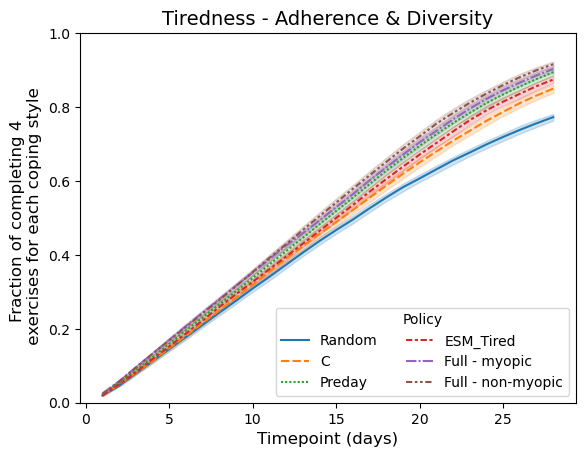

In [10]:
TRACK = 4

results_random = get_fraction_completed_div(cs_simulation_results_random, TRACK, "Random")
results_c = get_fraction_completed_div(cs_simulation_results_c, TRACK, "C")
results_preday = get_fraction_completed_div(cs_simulation_results_preday, TRACK, "Preday")
results_ESM = get_fraction_completed_div(cs_simulation_results_ESM, TRACK, "ESM_Tired")
results_full_nf = get_fraction_completed_div(cs_simulation_results_full_nf, TRACK, "Full - myopic")
results_full = get_fraction_completed_div(cs_simulation_results_full, TRACK, "Full - non-myopic")


frac_all = pd.concat([results_random, results_c, results_preday, results_ESM, results_full_nf, results_full])

sns.lineplot(data = frac_all, x = "day", y = "fraction", hue = "Policy", style = "Policy")
plt.xlabel("Timepoint (days)", fontsize = 12)
plt.ylabel("Fraction of completing 4 \n exercises for each coping style", fontsize = 12)
plt.title("Tiredness - Adherence & Diversity", fontsize = 14)
plt.ylim(0, 1)
plt.legend(fontsize = 10, ncol = 2, loc = "lower right", title = "Policy")
plt.savefig("Figures/TIR_ActionCount_2each_div_c.png", dpi = 300)

Let's assess the improvement on the diversity measure for the full models 

In [9]:
res_full = results_full[results_full['day'] == 28]['fraction'].mean() 
res_random = results_random[results_random['day'] == 28]['fraction'].mean() 
res_full_nf = results_full_nf[results_full_nf['day'] == 28]['fraction'].mean() 
res_c = results_c[results_c['day'] == 28]['fraction'].mean() 
res_preday = results_preday[results_preday['day'] == 28]['fraction'].mean() 
res_ESM = results_ESM[results_ESM['day'] == 28]['fraction'].mean() 

print("improvement of full model nf:", np.round((res_full_nf - res_random) / res_random * 100, 1))
print("improvement of full model:", np.round((res_full - res_random) / res_random * 100))
print("improvement of c:", np.round((res_c - res_random) / res_random * 100))
print("improvement of preday:", np.round((res_preday - res_random) / res_random * 100))
print("improvement of ESM:", np.round((res_ESM - res_random) / res_random * 100))

improvement of full model nf: 16.9
improvement of full model: 19.0
improvement of c: 10.0
improvement of preday: 16.0
improvement of ESM: 13.0
